# Notebook 4: Feature Analysis and Modeling Preparation

## Project: Diabetes Glucose Analysis

This notebook continues from the completed exploratory data analysis notebook.

The goal of this notebook is to prepare the cleaned diabetes glucose dataset for machine learning modeling.

This notebook focuses on:

- loading the processed dataset
- applying universal chart styling
- reviewing available features
- planning target variables
- selecting modeling features
- checking missing values
- avoiding data leakage
- preparing train-test split strategies
- preparing baseline modeling datasets
- saving modeling-ready files

## Step 1: Import Required Libraries

In this step, we import the libraries needed for data analysis, visualization, and modeling preparation.

We use:

- `pandas` for data manipulation
- `numpy` for numerical operations
- `matplotlib` and `seaborn` for visualizations
- `train_test_split` for random splitting
- `GroupShuffleSplit` for patient-level splitting

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GroupShuffleSplit

### Why this step is needed

These libraries provide the main tools required for this notebook.

Without these imports, Python will not recognize functions such as:

- `pd.read_csv()`
- `sns.histplot()`
- `plt.figure()`
- `train_test_split()`

### Consequence if skipped

The notebook will produce errors such as:

`NameError: name 'pd' is not defined`

or

`NameError: name 'sns' is not defined`

## Step 2: Universal Chart Styling Setup

This section defines a consistent visual style for all charts in the notebook.

Instead of setting colors, figure size, gridlines, font sizes, and save settings in every chart separately, we define them once at the beginning.

This helps make all visualizations look consistent and professional.

In [2]:
# Set global seaborn theme
sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="husl"
)

# Set default matplotlib figure size
plt.rcParams["figure.figsize"] = (12, 6)

# Set title and axis label sizes
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

# Set tick label sizes
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# Set legend font size
plt.rcParams["legend.fontsize"] = 10

# Set line width
plt.rcParams["lines.linewidth"] = 2

# Set grid transparency
plt.rcParams["grid.alpha"] = 0.3

# Set save quality
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["savefig.bbox"] = "tight"

print("Universal chart styling setup completed.")

Universal chart styling setup completed.


### Why this step is needed

This step automatically applies a consistent visual style to most charts created with Matplotlib and Seaborn.

It helps with:

- avoiding repeated styling code
- improving readability
- avoiding default blue-only charts
- creating GitHub-ready visualizations
- making the notebook look more professional

### Consequence if skipped

Charts may use inconsistent default formatting.

You may also need to manually define colors, figure size, font sizes, and gridlines for each chart.

## Step 3: Load Processed Data

In this step, we load the cleaned and processed dataset created in earlier notebooks.

We load:

- `diabetes_glucose_processed.csv`
- `patient_summary.csv`

The processed dataset will be used for modeling preparation.

In [3]:
df = pd.read_csv("../data/processed/diabetes_glucose_processed.csv")
patient_summary = pd.read_csv("../data/processed/patient_summary.csv")

df.head()

,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input,patient_id,time_diff,...,hour,day,day_of_week,date,time_period,glucose_lag_1,glucose_lag_3,glucose_lag_6,glucose_rolling_30min,glucose_rolling_1hr
0,2018-06-13 19:10:00,312.0,10.1430,91.339623,48.0,0.075,0.0,0.0,HUPA0001P,0 days 00:05:00,...,19,13,2,2018-06-13,evening,313.0,324.0,332.0,318.500000,320.428571
1,2018-06-13 19:15:00,293.0,6.8425,89.893443,0.0,0.075,0.0,0.0,HUPA0001P,0 days 00:05:00,...,19,13,2,2018-06-13,evening,312.0,306.0,326.0,313.000000,317.000000
2,2018-06-13 19:20:00,303.0,5.2325,89.352941,0.0,0.075,0.0,0.0,HUPA0001P,0 days 00:05:00,...,19,13,2,2018-06-13,evening,293.0,313.0,330.0,308.500000,315.444444
3,2018-06-13 19:25:00,293.0,8.0500,89.778761,77.0,0.075,0.0,0.0,HUPA0001P,0 days 00:05:00,...,19,13,2,2018-06-13,evening,303.0,312.0,324.0,303.333333,313.200000
4,2018-06-13 19:30:00,271.0,17.7905,104.536232,124.0,0.075,0.0,0.0,HUPA0001P,0 days 00:05:00,...,19,13,2,2018-06-13,evening,293.0,293.0,306.0,297.500000,309.363636


### Why this step is needed

This notebook should continue from the processed files created in Notebook 2 and explored in Notebook 3.

Using processed data avoids repeating cleaning steps.

### Consequence if skipped

You will not have a dataset available for feature selection, target planning, or train-test splitting.

## Step 4: Review Dataset Shape and Columns

Before preparing data for modeling, we review the size of the dataset and the available columns.

This helps us understand which columns can be used as features and which columns should be excluded.

In [4]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns)

Dataset shape: (309242, 21)

Columns:
Index(['time', 'glucose', 'calories', 'heart_rate', 'steps', 'basal_rate',
       'bolus_volume_delivered', 'carb_input', 'patient_id', 'time_diff',
       'glucose_category', 'hour', 'day', 'day_of_week', 'date', 'time_period',
       'glucose_lag_1', 'glucose_lag_3', 'glucose_lag_6',
       'glucose_rolling_30min', 'glucose_rolling_1hr'],
      dtype='str')


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 309242 entries, 0 to 309241
Data columns (total 21 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   time                    309242 non-null  str    
 1   glucose                 309242 non-null  float64
 2   calories                309242 non-null  float64
 3   heart_rate              309242 non-null  float64
 4   steps                   309242 non-null  float64
 5   basal_rate              309242 non-null  float64
 6   bolus_volume_delivered  309242 non-null  float64
 7   carb_input              309242 non-null  float64
 8   patient_id              309242 non-null  str    
 9   time_diff               309242 non-null  str    
 10  glucose_category        309242 non-null  str    
 11  hour                    309242 non-null  int64  
 12  day                     309242 non-null  int64  
 13  day_of_week             309242 non-null  int64  
 14  date                    309242 

### Why this step is needed

This step helps identify:

- numerical columns
- categorical columns
- datetime columns
- target columns
- columns that may cause data leakage

### Consequence if skipped

You may accidentally include incorrect columns in the model, such as target-derived columns or raw datetime fields.

## Step 5: Convert Time Column to Datetime

The `time` column should be converted to datetime format.

This is important because the dataset is time-series data, and we may need to sort, split, or analyze the data by time.

In [6]:
df["time"] = pd.to_datetime(df["time"])

df["time"].head()

0   2018-06-13 19:10:00
1   2018-06-13 19:15:00
2   2018-06-13 19:20:00
3   2018-06-13 19:25:00
4   2018-06-13 19:30:00
Name: time, dtype: datetime64[us]

### Why this step is needed

Datetime format allows Python to properly understand time-based values.

This is important for:

- chronological sorting
- time-series splitting
- extracting time-based features
- avoiding incorrect ordering

### Consequence if skipped

The `time` column may be treated as text.

This can cause incorrect sorting and unreliable time-series analysis.

## Step 6: Sort Data by Patient and Time

Since this is a time-series dataset with multiple patients, the data should be sorted by:

1. `patient_id`
2. `time`

This ensures that each patient's records are arranged chronologically.

In [7]:
df = df.sort_values(["patient_id", "time"]).reset_index(drop=True)

df[["patient_id", "time", "glucose"]].head()

,patient_id,time,glucose
0,HUPA0001P,2018-06-13 19:10:00,312.0
1,HUPA0001P,2018-06-13 19:15:00,293.0
2,HUPA0001P,2018-06-13 19:20:00,303.0
3,HUPA0001P,2018-06-13 19:25:00,293.0
4,HUPA0001P,2018-06-13 19:30:00,271.0


### Why this step is needed

Time-series data depends on correct order.

Sorting ensures that past records appear before future records.

### Consequence if skipped

Lag features, rolling features, and chronological splits may become unreliable if the data is not ordered correctly.

## Step 7: Quick Glucose Distribution Check

Before modeling preparation, we quickly review the glucose distribution again.

This helps confirm that the target variable is available and reasonable.

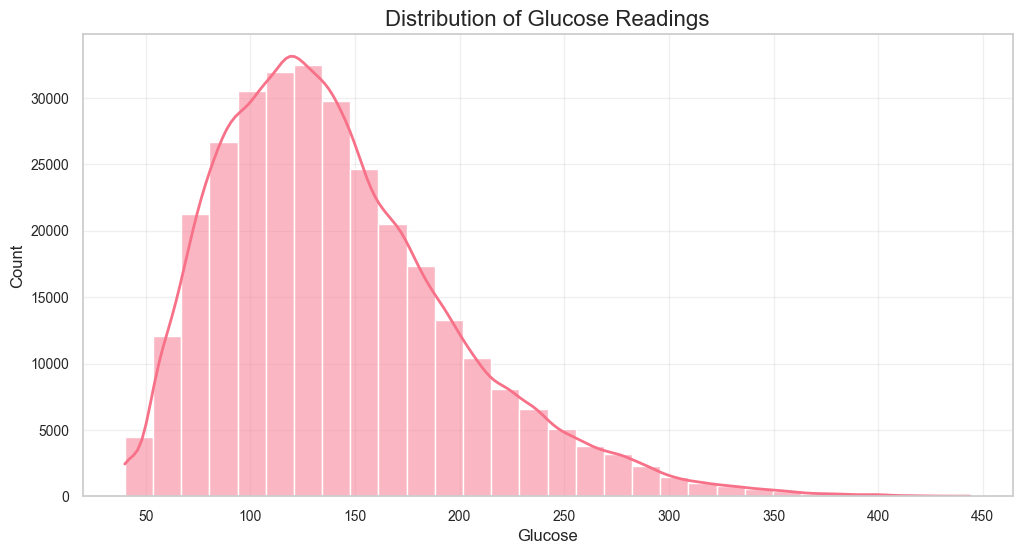

In [8]:
plt.figure()
sns.histplot(data=df, x="glucose", bins=30, kde=True)
plt.title("Distribution of Glucose Readings")
plt.xlabel("Glucose")
plt.ylabel("Count")
plt.show()

### Why this step is needed

The glucose column is the main target for regression modeling.

Checking its distribution helps us understand:

- whether glucose values are spread normally
- whether there are extreme values
- whether the target has enough variation

### Consequence if skipped

You may move into modeling without understanding the behavior of the target variable.

## Step 8: Target Variable Planning

A target variable is the value that the model will try to predict.

For this project, there are two possible modeling directions:

### Option 1: Regression

Predict the actual glucose value.

Target:

`glucose`

### Option 2: Classification

Predict the glucose category.

Target:

`glucose_category`

In this notebook, we prepare primarily for regression modeling because glucose is naturally a continuous numerical value.

In [9]:
target_regression = "glucose"
target_classification = "glucose_category"

print("Regression target:", target_regression)
print("Classification target:", target_classification)

Regression target: glucose
Classification target: glucose_category


### Why this step is needed

Target planning helps define the modeling goal clearly.

Without a clear target, we cannot correctly separate input features from the output variable.

### Consequence if skipped

The model may be built with an unclear objective or may accidentally use the target as an input feature.

## Step 9: Identify Columns to Exclude

Some columns should not be used as model input features.

These include:

- the target variable
- columns derived directly from the target
- raw datetime columns
- columns that are not immediately model-ready

In [10]:
exclude_columns = [
    "glucose",
    "glucose_category",
    "time",
    "date"
]

exclude_columns

['glucose', 'glucose_category', 'time', 'date']

### Why this step is needed

This step helps prevent data leakage.

For example, `glucose_category` is created from `glucose`, so using it to predict glucose would give the model unfair information.

### Consequence if skipped

The model may produce unrealistically high accuracy because it has access to information it should not know.

## Step 10: Create Candidate Feature List

Candidate features are the columns that may be used as input variables for modeling.

We create this list by excluding target-related and non-model-ready columns.

In [11]:
candidate_features = [
    col for col in df.columns
    if col not in exclude_columns
]

candidate_features

['calories',
 'heart_rate',
 'steps',
 'basal_rate',
 'bolus_volume_delivered',
 'carb_input',
 'patient_id',
 'time_diff',
 'hour',
 'day',
 'day_of_week',
 'time_period',
 'glucose_lag_1',
 'glucose_lag_3',
 'glucose_lag_6',
 'glucose_rolling_30min',
 'glucose_rolling_1hr']

In [12]:
df[candidate_features].head()

,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input,patient_id,time_diff,hour,day,day_of_week,time_period,glucose_lag_1,glucose_lag_3,glucose_lag_6,glucose_rolling_30min,glucose_rolling_1hr
0,10.1430,91.339623,48.0,0.075,0.0,0.0,HUPA0001P,0 days 00:05:00,19,13,2,evening,313.0,324.0,332.0,318.500000,320.428571
1,6.8425,89.893443,0.0,0.075,0.0,0.0,HUPA0001P,0 days 00:05:00,19,13,2,evening,312.0,306.0,326.0,313.000000,317.000000
2,5.2325,89.352941,0.0,0.075,0.0,0.0,HUPA0001P,0 days 00:05:00,19,13,2,evening,293.0,313.0,330.0,308.500000,315.444444
3,8.0500,89.778761,77.0,0.075,0.0,0.0,HUPA0001P,0 days 00:05:00,19,13,2,evening,303.0,312.0,324.0,303.333333,313.200000
4,17.7905,104.536232,124.0,0.075,0.0,0.0,HUPA0001P,0 days 00:05:00,19,13,2,evening,293.0,293.0,306.0,297.500000,309.363636


### Why this step is needed

This creates an organized list of possible model inputs.

These may include:

- patient information
- time-based features
- activity features
- insulin features
- carbohydrate features
- lag glucose features
- rolling glucose features

### Consequence if skipped

Feature selection becomes disorganized and increases the chance of accidentally using incorrect columns.

## Step 11: Check Missing Values in Candidate Features

Machine learning models usually require complete input values.

This step checks how many missing values exist in the candidate feature columns.

In [13]:
missing_values = df[candidate_features].isna().sum().sort_values(ascending=False)

missing_values[missing_values > 0]

Series([], dtype: int64)

### Why this step is needed

Missing values can occur because of:

- sensor gaps
- unavailable activity records
- unavailable nutrition records
- lag feature creation
- rolling feature creation

### Consequence if skipped

Model training may fail or produce unreliable results.

## Step 12: Create Modeling Dataset

For the first baseline modeling workflow, we remove rows that contain missing values in the selected candidate features or target variable.

This is a simple and transparent approach for baseline preparation.

In [14]:
model_df = df.dropna(subset=candidate_features + [target_regression]).copy()

print("Original dataset shape:", df.shape)
print("Modeling dataset shape:", model_df.shape)

Original dataset shape: (309242, 21)
Modeling dataset shape: (309242, 21)


### Why this step is needed

Baseline models need clean data without missing values.

Dropping missing values is simple and easy to explain.

### Consequence if skipped

Many machine learning models may throw errors when they encounter missing values.

Later notebooks can improve this by using imputation methods.

## Step 13: Select Numeric Features

For baseline modeling, we start with numerical features only.

This avoids the need for categorical encoding in the first modeling workflow.

In [15]:
numeric_features = model_df[candidate_features].select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

numeric_features

['calories',
 'heart_rate',
 'steps',
 'basal_rate',
 'bolus_volume_delivered',
 'carb_input',
 'hour',
 'day',
 'day_of_week',
 'glucose_lag_1',
 'glucose_lag_3',
 'glucose_lag_6',
 'glucose_rolling_30min',
 'glucose_rolling_1hr']

In [16]:
print("Number of numeric features selected:", len(numeric_features))

Number of numeric features selected: 14


### Why this step is needed

Most baseline machine learning models require numerical inputs.

Starting with numerical features keeps the first modeling workflow simple and reliable.

### Consequence if skipped

The model may fail if non-numeric columns are included without encoding.

## Step 14: Review Selected Modeling Features

In this step, we inspect the final selected features that will be used for baseline modeling.

In [17]:
model_df[numeric_features].head()

,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input,hour,day,day_of_week,glucose_lag_1,glucose_lag_3,glucose_lag_6,glucose_rolling_30min,glucose_rolling_1hr
0,10.1430,91.339623,48.0,0.075,0.0,0.0,19,13,2,313.0,324.0,332.0,318.500000,320.428571
1,6.8425,89.893443,0.0,0.075,0.0,0.0,19,13,2,312.0,306.0,326.0,313.000000,317.000000
2,5.2325,89.352941,0.0,0.075,0.0,0.0,19,13,2,293.0,313.0,330.0,308.500000,315.444444
3,8.0500,89.778761,77.0,0.075,0.0,0.0,19,13,2,303.0,312.0,324.0,303.333333,313.200000
4,17.7905,104.536232,124.0,0.075,0.0,0.0,19,13,2,293.0,293.0,306.0,297.500000,309.363636


### Why this step is needed

This step confirms that the selected features look correct before splitting the data.

### Consequence if skipped

You may not notice problematic columns until later during model training.

## Step 15: Feature Correlation with Target

This step checks how strongly each numerical feature is correlated with glucose.

This helps identify which features may be useful for prediction.

In [18]:
correlation_with_target = model_df[numeric_features + [target_regression]].corr()[target_regression].sort_values(ascending=False)

correlation_with_target

glucose                   1.000000
glucose_lag_1             0.995755
glucose_rolling_30min     0.986738
glucose_lag_3             0.979468
glucose_rolling_1hr       0.953553
glucose_lag_6             0.934794
heart_rate                0.098395
hour                      0.057364
steps                     0.051336
bolus_volume_delivered    0.020141
calories                  0.008571
day_of_week               0.000301
carb_input               -0.001037
day                      -0.013187
basal_rate               -0.022837
Name: glucose, dtype: float64

### Why this step is needed

Correlation gives a quick indication of which features are related to glucose.

Features with stronger correlation may be more useful for modeling.

### Consequence if skipped

You may miss important relationships between features and the target variable.

## Step 16: Visualize Top Feature Correlations

This chart shows the features most strongly related to glucose.

The universal chart styling defined at the beginning will automatically apply.

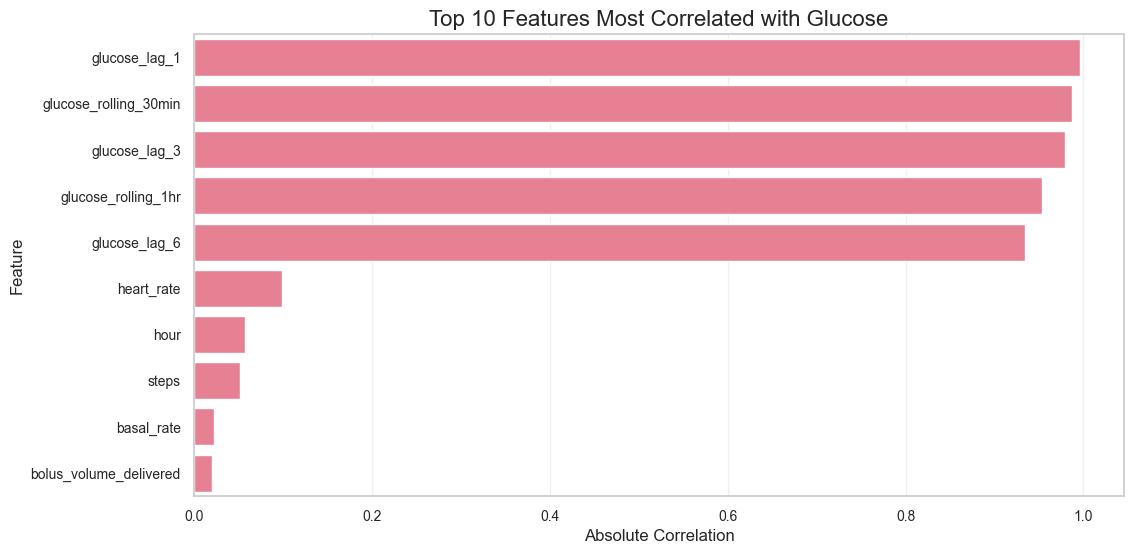

In [19]:
top_correlations = correlation_with_target.drop(target_regression).abs().sort_values(ascending=False).head(10)

plt.figure()
sns.barplot(
    x=top_correlations.values,
    y=top_correlations.index
)
plt.title("Top 10 Features Most Correlated with Glucose")
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")
plt.show()

### Why this step is needed

A visual chart makes it easier to understand which features may be important.

### Consequence if skipped

You can still continue, but the notebook will be less interpretable.

## Step 17: Data Leakage Review

Data leakage happens when the model uses information that would not be available at prediction time.

For this project, possible leakage risks include:

1. Using `glucose_category` to predict `glucose`
2. Using future glucose values in rolling features
3. Randomly mixing time-series records
4. Mixing the same patient across train and test data without considering evaluation goals
5. Using target-derived columns as input features

To reduce leakage, this notebook excludes direct target-related columns and prepares multiple split strategies.

In [20]:
leakage_check_columns = [
    col for col in numeric_features
    if "glucose" in col.lower()
]

leakage_check_columns

['glucose_lag_1',
 'glucose_lag_3',
 'glucose_lag_6',
 'glucose_rolling_30min',
 'glucose_rolling_1hr']

### Why this step is needed

Some glucose-related features may be valid, such as lag glucose or rolling glucose features, if they were created using past values only.

However, they should be reviewed carefully.

### Consequence if skipped

The model may learn from future or target-derived information, leading to misleading results.

## Step 18: Define X and y

In machine learning:

- `X` represents the input features
- `y` represents the target variable

Here, we use numerical features to predict glucose.

In [21]:
X = model_df[numeric_features]
y = model_df[target_regression]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (309242, 14)
y shape: (309242,)


### Why this step is needed

This separates the input features from the target variable.

### Consequence if skipped

The model will not know which columns are inputs and which column is the prediction target.

## Step 19: Random Train-Test Split

A random split divides the dataset into training and testing sets randomly.

This is useful as a simple baseline.

In [22]:
X_train_random, X_test_random, y_train_random, y_test_random = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Random train shape:", X_train_random.shape)
print("Random test shape:", X_test_random.shape)

Random train shape: (247393, 14)
Random test shape: (61849, 14)


### Why this step is needed

Random split gives a simple first version of train-test data.

It is commonly used as a baseline.

### Consequence if skipped

You will not have a simple baseline split for initial model testing.

### Important limitation

For time-series data, random splitting can overestimate performance because nearby records from the same patient may appear in both training and testing data.

## Step 20: Chronological Train-Test Split

A chronological split trains on earlier records and tests on later records.

This better reflects real-world time-series prediction.

In [23]:
split_index = int(len(model_df) * 0.8)

train_chrono = model_df.iloc[:split_index]
test_chrono = model_df.iloc[split_index:]

X_train_chrono = train_chrono[numeric_features]
y_train_chrono = train_chrono[target_regression]

X_test_chrono = test_chrono[numeric_features]
y_test_chrono = test_chrono[target_regression]

print("Chronological train shape:", X_train_chrono.shape)
print("Chronological test shape:", X_test_chrono.shape)

Chronological train shape: (247393, 14)
Chronological test shape: (61849, 14)


### Why this step is needed

Time-series models should ideally be trained on past data and tested on future data.

This gives a more realistic evaluation.

### Consequence if skipped

The project may rely only on random split results, which can be overly optimistic.

## Step 21: Patient-Level Train-Test Split

A patient-level split separates patients between training and testing sets.

This tests whether the model can generalize to patients it has never seen before.

In [24]:
groups = model_df["patient_id"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(model_df, y, groups))

train_patient = model_df.iloc[train_idx]
test_patient = model_df.iloc[test_idx]

X_train_patient = train_patient[numeric_features]
y_train_patient = train_patient[target_regression]

X_test_patient = test_patient[numeric_features]
y_test_patient = test_patient[target_regression]

print("Patient-level train shape:", X_train_patient.shape)
print("Patient-level test shape:", X_test_patient.shape)

print("Number of train patients:", train_patient["patient_id"].nunique())
print("Number of test patients:", test_patient["patient_id"].nunique())

Patient-level train shape: (130240, 14)
Patient-level test shape: (179002, 14)
Number of train patients: 20
Number of test patients: 5


### Why this step is needed

This split is useful when the goal is to build a model that works on new patients.

It prevents the same patient from appearing in both train and test sets.

### Consequence if skipped

The model may perform well only because it has already seen the same patients during training.

## Step 22: Compare Split Strategies

Different split strategies answer different modeling questions.

| Split Strategy | Purpose | Main Risk |
|---|---|---|
| Random split | Simple baseline | May overestimate performance |
| Chronological split | Future prediction | Same patients may appear in train and test |
| Patient-level split | New patient generalization | More difficult task |

For this project, all three splits are useful because they give different views of model performance.

In [25]:
split_summary = pd.DataFrame({
    "split_type": ["Random", "Chronological", "Patient-level"],
    "train_rows": [
        X_train_random.shape[0],
        X_train_chrono.shape[0],
        X_train_patient.shape[0]
    ],
    "test_rows": [
        X_test_random.shape[0],
        X_test_chrono.shape[0],
        X_test_patient.shape[0]
    ],
    "train_features": [
        X_train_random.shape[1],
        X_train_chrono.shape[1],
        X_train_patient.shape[1]
    ]
})

split_summary

,split_type,train_rows,test_rows,train_features
0,Random,247393,61849,14
1,Chronological,247393,61849,14
2,Patient-level,130240,179002,14


### Why this step is needed

This gives a clear comparison of the prepared train-test splits.

### Consequence if skipped

It becomes harder to verify whether the splits were created correctly.

## Step 23: Prepare Baseline Modeling Datasets

This step organizes all train-test splits into one dictionary.

This makes it easier to use them in the next modeling notebook.

In [26]:
baseline_data = {
    "random_split": {
        "X_train": X_train_random,
        "X_test": X_test_random,
        "y_train": y_train_random,
        "y_test": y_test_random
    },
    "chronological_split": {
        "X_train": X_train_chrono,
        "X_test": X_test_chrono,
        "y_train": y_train_chrono,
        "y_test": y_test_chrono
    },
    "patient_level_split": {
        "X_train": X_train_patient,
        "X_test": X_test_patient,
        "y_train": y_train_patient,
        "y_test": y_test_patient
    }
}

baseline_data.keys()

dict_keys(['random_split', 'chronological_split', 'patient_level_split'])

### Why this step is needed

This keeps the notebook organized and prepares the project for baseline modeling.

### Consequence if skipped

You may need to recreate the splits manually in the next notebook.

## Step 24: Save Modeling-Ready Dataset

In this step, we save the cleaned modeling dataset to the processed data folder.

This file can be loaded directly in the next notebook.

In [27]:
model_df.to_csv("../data/processed/modeling_ready_dataset.csv", index=False)

print("Modeling-ready dataset saved successfully.")

Modeling-ready dataset saved successfully.


### Why this step is needed

Saving the modeling-ready dataset improves reproducibility.

Notebook 5 can start directly from this file.

### Consequence if skipped

You may need to repeat the modeling preparation steps in future notebooks.

## Step 25: Save Modeling Feature List

This step saves the final list of selected modeling features.

This is useful for documentation and reproducibility.

In [28]:
feature_list = pd.DataFrame({
    "feature_name": numeric_features
})

feature_list.to_csv("../data/processed/modeling_feature_list.csv", index=False)

feature_list.head()

,feature_name
0,calories
1,heart_rate
2,steps
3,basal_rate
4,bolus_volume_delivered


### Why this step is needed

The feature list clearly documents which columns were selected for baseline modeling.

This is helpful for GitHub, project review, and future model comparison.

### Consequence if skipped

It may be unclear which features were used during modeling.

## Key Findings

- The processed diabetes glucose dataset was successfully loaded.
- A universal chart styling setup was applied to make visualizations consistent.
- The glucose column was selected as the primary regression target.
- Candidate modeling features were selected after excluding target-related and non-model-ready columns.
- Missing values were checked before modeling preparation.
- A modeling-ready dataset was created.
- Numerical features were selected for baseline modeling.
- Correlation with glucose was reviewed to understand feature relationships.
- Data leakage risks were identified.
- Three train-test split strategies were prepared:
  - random split
  - chronological split
  - patient-level split
- The modeling-ready dataset and feature list were saved for the next notebook.

## Challenges

- Time-series data requires careful ordering before splitting.
- Random train-test splitting may not reflect real-world prediction.
- Patient-level differences may make model generalization difficult.
- Lag and rolling glucose features must be checked carefully to avoid data leakage.
- Some rows may be removed due to missing values.
- Non-numeric features require additional encoding before they can be used in modeling.

## Next Steps

The next notebook will be:

`05_baseline_modeling.ipynb`

It will focus on:

- loading the modeling-ready dataset
- loading the selected feature list
- training baseline regression models
- evaluating model performance
- comparing random, chronological, and patient-level splits
- saving baseline model results